In [9]:
#1.Import all libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pennylane as qml
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

In [10]:
#2. Dataset preparation
torch.manual_seed(42)
np.random.seed(42)

def generate_bas_4x4(num_samples=800, noise_std=0.1):
    X, y = [], []
    for _ in range(num_samples):
        img = np.zeros((4, 4))
        if np.random.rand() > 0.5:
            # Class 0: horizontal stripes  
            rows = np.random.choice(4, np.random.randint(1, 4), replace=False)
            img[rows, :] = 1
            y.append(0)
        else:
            # Class 1: vertical stripes
            cols = np.random.choice(4, np.random.randint(1, 4), replace=False)
            img[:, cols] = 1
            y.append(1)
            
        # Add Gaussian noise and flatten to 16 dimensions
        X.append(img.flatten() + np.random.normal(0, noise_std, 16))
    return np.array(X), np.array(y)

# Generate 800 samples of 16 dimensions
X_raw, y_raw = generate_bas_4x4(num_samples=800, noise_std=0.1)

# Split into training and test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Compress 16 pixels into 4 features to increase classification difficulty
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_raw)
X_test_pca = pca.transform(X_test_raw)

# ==================== Normalize to [0, π] ====================
# Map to [0, π] range to accommodate quantum rotation gates (Angle Embedding)
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train_pca)
X_test_scaled = scaler.transform(X_test_pca)

# Convert to PyTorch Tensor
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [11]:
#3. QNN model definition
n_qubits = 4  # Corresponds to 4 features after PCA dimensionality reduction
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qnode(inputs, weights):
    # Use angle encoding to map 4 PCA features to 4 qubits
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    #  Entanglement layer
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

n_layers = 6
weight_shapes = {"weights": (n_layers, n_qubits)}

class QNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
        self.post = nn.Linear(n_qubits, 2)
    
    def forward(self, x):
        x = self.qlayer(x)
        return self.post(x)

In [12]:
#4. ANN model definition
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        # For fair comparison, input dimension is also set to 4 
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )
   
    def forward(self, x):
        return self.net(x)

In [13]:
#5.Generic training function
def train_model(model, loader, epochs=30, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for bx, by in loader:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        history.append(avg_loss)
        print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f}")
    return history

In [19]:
#6.Train QNN + timing
qnn_model = QNN()
start = time.time()
qnn_history = train_model(qnn_model, train_loader, epochs=30, lr=0.01)
qnn_time = time.time() - start

Epoch  1 | Loss: 0.6926
Epoch  2 | Loss: 0.6439
Epoch  3 | Loss: 0.5894
Epoch  4 | Loss: 0.5372
Epoch  5 | Loss: 0.4766
Epoch  6 | Loss: 0.4215
Epoch  7 | Loss: 0.3904
Epoch  8 | Loss: 0.3701
Epoch  9 | Loss: 0.3536
Epoch 10 | Loss: 0.3359
Epoch 11 | Loss: 0.3256
Epoch 12 | Loss: 0.3127
Epoch 13 | Loss: 0.3024
Epoch 14 | Loss: 0.2922
Epoch 15 | Loss: 0.2828
Epoch 16 | Loss: 0.2757
Epoch 17 | Loss: 0.2681
Epoch 18 | Loss: 0.2612
Epoch 19 | Loss: 0.2556
Epoch 20 | Loss: 0.2500
Epoch 21 | Loss: 0.2428
Epoch 22 | Loss: 0.2427
Epoch 23 | Loss: 0.2355
Epoch 24 | Loss: 0.2281
Epoch 25 | Loss: 0.2281
Epoch 26 | Loss: 0.2189
Epoch 27 | Loss: 0.2154
Epoch 28 | Loss: 0.2094
Epoch 29 | Loss: 0.2052
Epoch 30 | Loss: 0.2007


In [15]:
#7.Train ANN + timing
ann_model = ANN()
start = time.time()
ann_history = train_model(ann_model, train_loader, epochs=30, lr=0.01)
ann_time = time.time() - start

Epoch  1 | Loss: 0.6877
Epoch  2 | Loss: 0.6020
Epoch  3 | Loss: 0.4575
Epoch  4 | Loss: 0.3075
Epoch  5 | Loss: 0.2313
Epoch  6 | Loss: 0.1750
Epoch  7 | Loss: 0.1483
Epoch  8 | Loss: 0.1178
Epoch  9 | Loss: 0.1043
Epoch 10 | Loss: 0.0914
Epoch 11 | Loss: 0.0927
Epoch 12 | Loss: 0.0878
Epoch 13 | Loss: 0.0605
Epoch 14 | Loss: 0.0551
Epoch 15 | Loss: 0.0619
Epoch 16 | Loss: 0.0518
Epoch 17 | Loss: 0.0465
Epoch 18 | Loss: 0.0532
Epoch 19 | Loss: 0.0694
Epoch 20 | Loss: 0.0748
Epoch 21 | Loss: 0.0355
Epoch 22 | Loss: 0.0252
Epoch 23 | Loss: 0.0241
Epoch 24 | Loss: 0.0257
Epoch 25 | Loss: 0.0228
Epoch 26 | Loss: 0.0219
Epoch 27 | Loss: 0.0234
Epoch 28 | Loss: 0.0193
Epoch 29 | Loss: 0.0196
Epoch 30 | Loss: 0.0229


In [16]:
#8.Evaluation function + print results
@torch.no_grad()
def evaluate(model, X_t, y_t):
    model.eval()
    logits = model(X_t)
    preds = torch.argmax(logits, dim=1).numpy()
    probs = nn.functional.softmax(logits, dim=1)[:, 1].numpy()
    
    acc = accuracy_score(y_t.numpy(), preds)
    prec = precision_score(y_t.numpy(), preds, zero_division=0)
    rec = recall_score(y_t.numpy(), preds, zero_division=0)
    f1 = f1_score(y_t.numpy(), preds, zero_division=0)
    auc = roc_auc_score(y_t.numpy(), probs)
    return acc, prec, rec, f1, auc, probs, preds

qnn_acc, qnn_prec, qnn_rec, qnn_f1, qnn_auc, qnn_probs, qnn_preds = evaluate(qnn_model, X_test, y_test)
ann_acc, ann_prec, ann_rec, ann_f1, ann_auc, ann_probs, ann_preds = evaluate(ann_model, X_test, y_test)

print("\n=== Results Comparison ===")
print(f"QNN - Acc: {qnn_acc:.4f} | Prec: {qnn_prec:.4f} | Rec: {qnn_rec:.4f} | F1: {qnn_f1:.4f} | AUC: {qnn_auc:.4f}")
print(f"ANN - Acc: {ann_acc:.4f} | Prec: {ann_prec:.4f} | Rec: {ann_rec:.4f} | F1: {ann_f1:.4f} | AUC: {ann_auc:.4f}")


=== Results Comparison ===
QNN - Acc: 0.9500 | Prec: 0.9506 | Rec: 0.9506 | F1: 0.9506 | AUC: 0.9902
ANN - Acc: 0.9812 | Prec: 0.9643 | Rec: 1.0000 | F1: 0.9818 | AUC: 1.0000


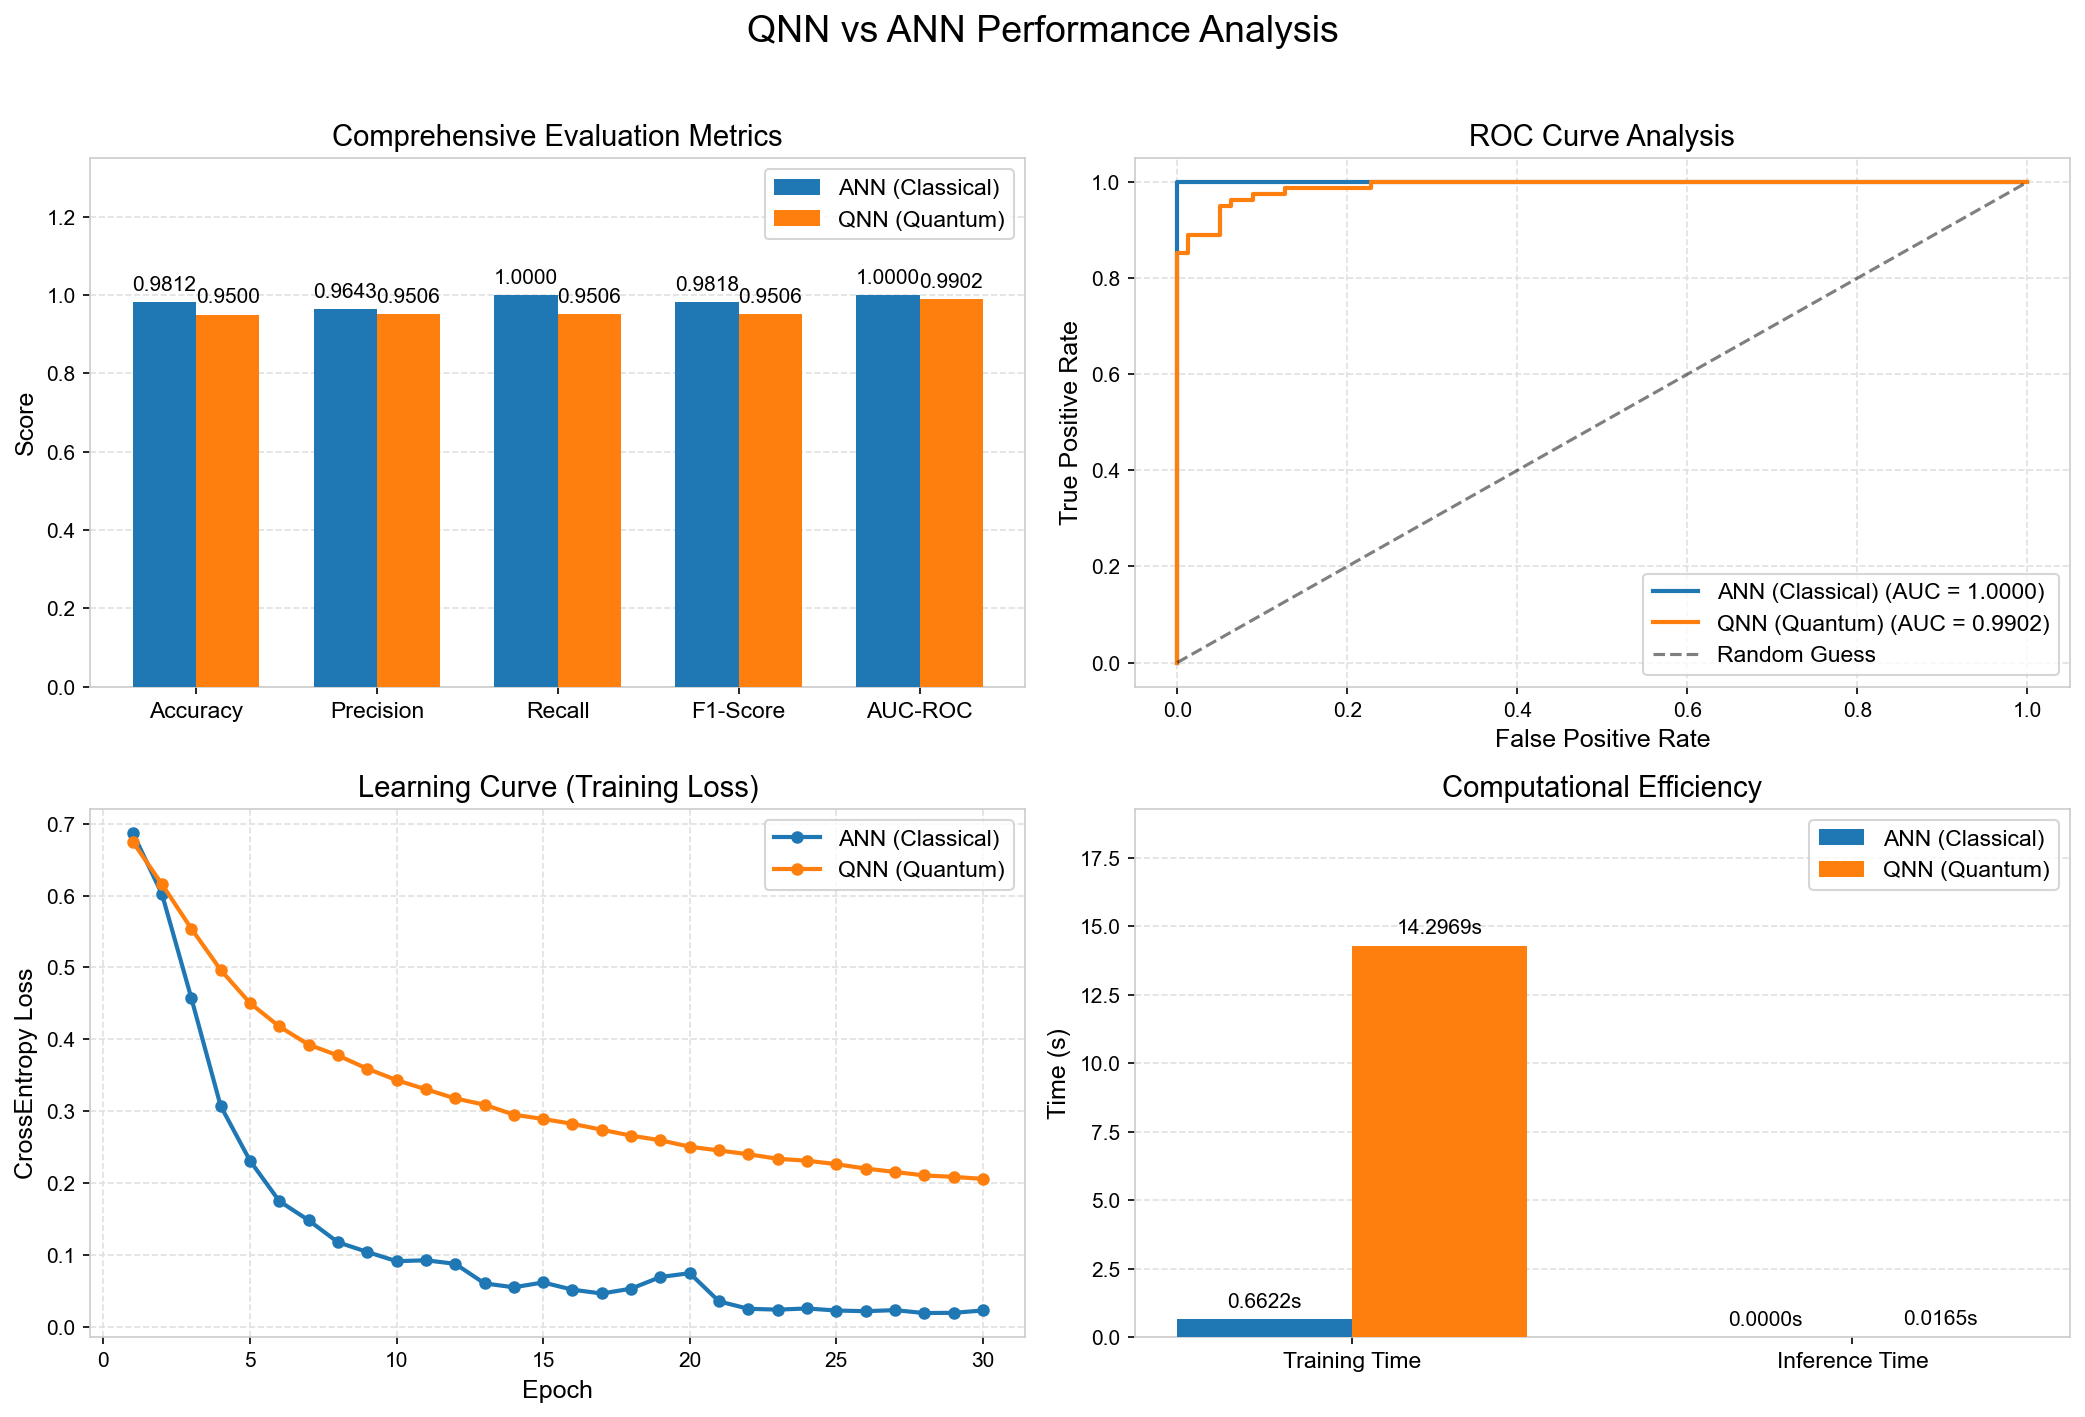

In [18]:
#9.Result Visualization
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import roc_curve

plt.rcParams.update({
    'font.sans-serif': ['Arial'], 
    'axes.edgecolor': '#cccccc',   
    'grid.color': '#e0e0e0',       
    'grid.linestyle': '--'       
})

# Calculate inference time
@torch.no_grad()
def get_inference_time(model, data):
    start = time.time()
    _ = model(data)
    return time.time() - start

qnn_inf_time = get_inference_time(qnn_model, X_test)
ann_inf_time = get_inference_time(ann_model, X_test)

classical_color = '#1f77b4'   
quantum_color   = '#ff7f0e'  

# Create canvas
fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
fig.suptitle('QNN vs ANN Performance Analysis', fontsize=18, y=0.98)

# ==================== Top-Left: Comprehensive Evaluation Metrics ====================
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
ann_vals = [ann_acc, ann_prec, ann_rec, ann_f1, ann_auc]
qnn_vals = [qnn_acc, qnn_prec, qnn_rec, qnn_f1, qnn_auc]

x = np.arange(len(metrics))
width = 0.35

for i in range(len(metrics)):
    axs[0,0].bar(x[i] - width/2, ann_vals[i], width, color=classical_color, 
                 label='ANN (Classical)' if i==0 else "", zorder=3)
    axs[0,0].bar(x[i] + width/2, qnn_vals[i], width, color=quantum_color, 
                 label='QNN (Quantum)' if i==0 else "", zorder=3)
    
    axs[0,0].text(x[i] - width/2, ann_vals[i] + 0.02, f'{ann_vals[i]:.4f}', 
                  ha='center', va='bottom', fontsize=10)
    axs[0,0].text(x[i] + width/2, qnn_vals[i] + 0.02, f'{qnn_vals[i]:.4f}', 
                  ha='center', va='bottom', fontsize=10)

axs[0,0].set_ylabel('Score', fontsize=12)
axs[0,0].set_title('Comprehensive Evaluation Metrics', fontsize=14)
axs[0,0].set_xticks(x)
axs[0,0].set_xticklabels(metrics, fontsize=11)

axs[0,0].set_ylim(0, 1.35) 
axs[0,0].legend(fontsize=11, loc='upper right')
axs[0,0].grid(axis='y', zorder=0)

# ==================== Top-Right: ROC Curve Analysis ====================
fpr_a, tpr_a, _ = roc_curve(y_test.numpy(), ann_probs)
fpr_q, tpr_q, _ = roc_curve(y_test.numpy(), qnn_probs)

axs[0,1].plot(fpr_a, tpr_a, label=f'ANN (Classical) (AUC = {ann_auc:.4f})', color=classical_color, lw=2)
axs[0,1].plot(fpr_q, tpr_q, label=f'QNN (Quantum) (AUC = {qnn_auc:.4f})', color=quantum_color, lw=2)
axs[0,1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Random Guess')
axs[0,1].set_xlabel('False Positive Rate', fontsize=12)
axs[0,1].set_ylabel('True Positive Rate', fontsize=12)
axs[0,1].set_title('ROC Curve Analysis', fontsize=14)

axs[0,1].legend(fontsize=11, loc='lower right') 
axs[0,1].grid(True)

# ==================== Bottom-Left: Learning Curve ====================
axs[1,0].plot(range(1, len(ann_history)+1), ann_history, 
              label='ANN (Classical)', color=classical_color, lw=2, marker='o', markersize=5)
axs[1,0].plot(range(1, len(qnn_history)+1), qnn_history, 
              label='QNN (Quantum)', color=quantum_color, lw=2, marker='o', markersize=5)
axs[1,0].set_title('Learning Curve (Training Loss)', fontsize=14)
axs[1,0].set_xlabel('Epoch', fontsize=12)
axs[1,0].set_ylabel('CrossEntropy Loss', fontsize=12)

axs[1,0].legend(fontsize=11, loc='upper right')
axs[1,0].grid(True)

# ==================== Bottom-Right: Computational Efficiency ====================
eff_labels = ['Training Time', 'Inference Time']
ann_eff = [ann_time, ann_inf_time]
qnn_eff = [qnn_time, qnn_inf_time]
x_eff = np.arange(len(eff_labels))

axs[1,1].bar(x_eff - width/2, ann_eff, width, color=classical_color, label='ANN (Classical)', zorder=3)
axs[1,1].bar(x_eff + width/2, qnn_eff, width, color=quantum_color, label='QNN (Quantum)', zorder=3)

axs[1,1].set_xticks(x_eff)
axs[1,1].set_xticklabels(eff_labels, fontsize=11)
axs[1,1].set_ylabel('Time (s)', fontsize=12)
axs[1,1].set_title('Computational Efficiency', fontsize=14)

max_time = max(max(ann_eff), max(qnn_eff))

axs[1,1].set_ylim(0, max_time * 1.35)
axs[1,1].legend(fontsize=11, loc='upper right')

offset = max_time * 0.02
for i in range(2):
    axs[1,1].text(x_eff[i] - width/2, ann_eff[i] + offset, f'{ann_eff[i]:.4f}s', 
                  ha='center', va='bottom', fontsize=10)
    axs[1,1].text(x_eff[i] + width/2, qnn_eff[i] + offset, f'{qnn_eff[i]:.4f}s', 
                  ha='center', va='bottom', fontsize=10)

axs[1,1].grid(axis='y', zorder=0)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()